In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from IPython.display import Audio
import librosa
import librosa.display

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [2]:
data_dir = 'E:\\Capstone\\Dataset\\Audio'

In [3]:
# Initialize empty lists for features and labels
features = []
labels = []
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        emotion_label = folder.split('_')[-1]  # Extract the emotion label from the folder name
        print(emotion_label)

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if file_path.endswith('.wav'):
                # Load the audio file and extract features
                audio, sr = librosa.load(file_path, duration=3)  # Adjust the duration as needed
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40) #13
                mfcc_mean = np.mean(mfcc, axis=1)
                features.append(mfcc_mean)
                labels.append(emotion_label)


Angry
Disgust
Fear
Happy
Neutral
Sad
Surprise


In [4]:
features = np.array(features)
labels = np.array(labels)

In [5]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

In [6]:
# Define the emotions and the number of samples to select from each emotion
emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad','Surprise']
num_samples_per_emotion = 2
# Initialize empty lists for storing the selected samples
selected_samples = []

In [7]:
# Iterate through the emotions and select samples
for emotion in emotions:
    emotion_dir = os.path.join(data_dir, f'{emotion}')
    audio_files = os.listdir(emotion_dir)
    selected_files = np.random.choice(audio_files, size=num_samples_per_emotion, replace=False)
    
    for file_name in selected_files:
        file_path = os.path.join(emotion_dir, file_name)
        audio, sr = librosa.load(file_path, duration=3)
        selected_samples.append((audio, sr, emotion))


In [8]:
for i in range(len(selected_samples)):
    print(selected_samples[i][-1])

Angry
Angry
Disgust
Disgust
Fear
Fear
Happy
Happy
Neutral
Neutral
Sad
Sad
Surprise
Surprise


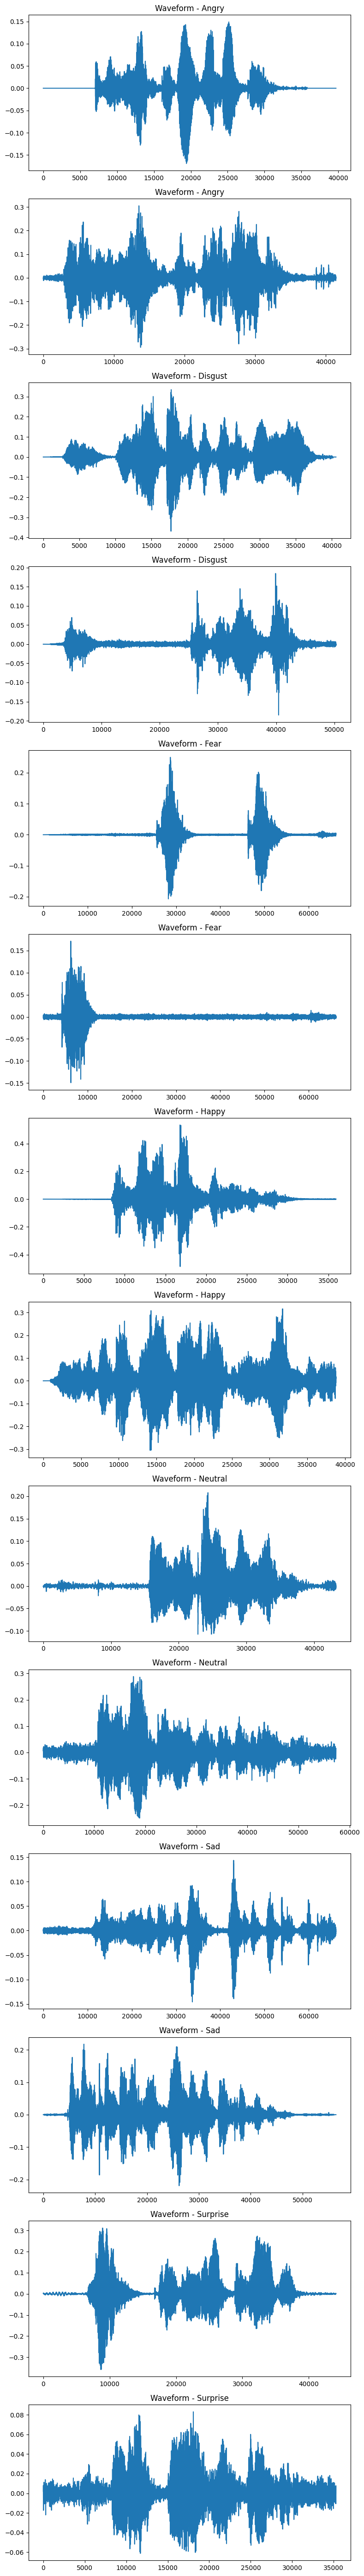

In [9]:
# Plot the selected samples
num_samples = len(selected_samples)
plt.figure(figsize=(8, 4 * num_samples))

for i, (audio, sr, emotion) in enumerate(selected_samples):
    plt.subplot(num_samples, 1, i + 1)
    plt.plot(audio)
    plt.title(f'Waveform - {emotion}')

plt.tight_layout()
plt.show()


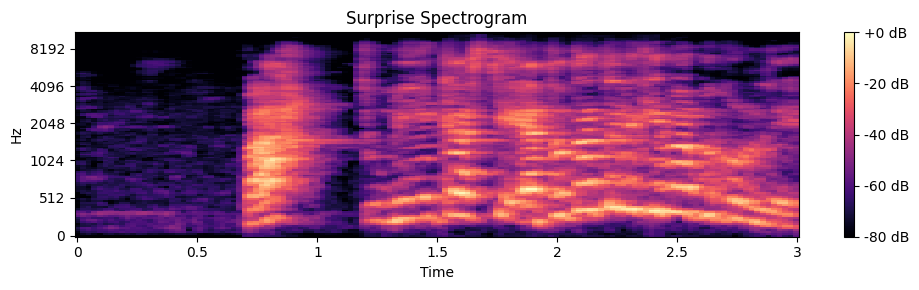

In [9]:
# Calculate the spectrogram
spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr)

# Convert power spectrogram to dB scale
spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

# Plot the spectrogram
plt.figure(figsize=(10, 3))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Surprise Spectrogram')
plt.tight_layout()
plt.show()
Audio(file_path)

In [10]:
import numpy as np
import librosa

# Define your pitch function
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# Define your sampling rate
sampling_rate = 44100  # For example, adjust this according to your data

# Apply audio transformations (e.g., noise addition, time stretching, pitch shifting)
augmented_features = []
augmented_labels = []

for feature, label in zip(features, labels):
    augmented_features.append(feature)
    augmented_labels.append(label)
    
    # Apply noise addition
    noise = np.random.randn(len(feature))
    augmented_features.append(feature + 0.005 * noise)  # Adjust the noise magnitude as needed
    augmented_labels.append(label)
    
    # Apply time stretching
    stretched_feature = librosa.effects.time_stretch(feature, rate=1.2)  # Adjust the rate as needed
    padded_feature = np.pad(stretched_feature, (0, len(feature) - len(stretched_feature)), mode='constant')
    augmented_features.append(padded_feature)
    augmented_labels.append(label)
    
    # Apply pitch shifting
    pitch_shifted_feature = pitch(feature, sampling_rate)  # Assuming sampling_rate is defined
    max_len = len(feature)  # Assuming max_len is defined
    pitch_shifted_feature = np.pad(pitch_shifted_feature, (0, max_len - len(pitch_shifted_feature)), 'constant')
    augmented_features.append(pitch_shifted_feature)
    augmented_labels.append(label)

# Convert the augmented lists to NumPy arrays
augmented_features = np.array(augmented_features)
augmented_labels = np.array(augmented_labels)

# Print the number of original and augmented samples
print('Original samples:', len(features))
print('Augmented samples:', len(augmented_features))

Original samples: 1032
Augmented samples: 4128


In [11]:
# Define a list to store the preprocessed data
preprocessed_data = []
file_list = os.listdir(data_dir)
# Iterate over the files
for filename in file_list:
    file_path = os.path.join(data_dir, filename)
    
    # Skip non-audio files
    if not filename.endswith('.wav'):
        continue

    # Load the audio file and obtain the waveform and sample rate
    waveform, sr = librosa.load(file_path, sr=None, dtype=np.float32)

    # Resample the audio if needed
    if sr != 22050:
        waveform = librosa.resample(waveform, sr, 22050)
        sr = 22050


In [12]:
# Encode the emotion labels
label_mapping = {'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise' : 6}
encoded_labels = np.array([label_mapping[label] for label in augmented_labels])

# Convert the emotion labels to categorical format
num_classes = len(label_mapping)
y_categorical = to_categorical(encoded_labels, num_classes)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(augmented_features, y_categorical, test_size=0.2, random_state=42)

# Reshape the input features
X_train = X_train.reshape((*X_train.shape, 1))
X_test = X_test.reshape((*X_test.shape, 1))


In [13]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3302, 40, 1)
y_train shape: (3302, 7)
X_test shape: (826, 40, 1)
y_test shape: (826, 7)


In [48]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(7, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 256)               264192    
                                                                 
 dropout_26 (Dropout)        (None, 256)               0         
                                                                 
 dense_25 (Dense)            (None, 128)               32896     
                                                                 
 dropout_27 (Dropout)        (None, 128)               0         
                                                                 
 dense_26 (Dense)            (None, 64)                8256      
                                                                 
 dropout_28 (Dropout)        (None, 64)                0         
                                                                 
 dense_27 (Dense)            (None, 32)               

In [49]:
history = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test loss:", loss)
print("Test accuracy:", accuracy)

Epoch 1/100
104/104 [==============================] - 9s 56ms/step - loss: 1.9195 - accuracy: 0.1869 - val_loss: 1.9092 - val_accuracy: 0.2070
Epoch 2/100
104/104 [==============================] - 5s 50ms/step - loss: 1.8519 - accuracy: 0.2317 - val_loss: 1.7905 - val_accuracy: 0.2506
Epoch 3/100
104/104 [==============================] - 6s 59ms/step - loss: 1.7612 - accuracy: 0.3086 - val_loss: 1.7030 - val_accuracy: 0.3099
Epoch 4/100
104/104 [==============================] - 6s 56ms/step - loss: 1.6905 - accuracy: 0.3253 - val_loss: 1.5929 - val_accuracy: 0.3632
Epoch 5/100
104/104 [==============================] - 6s 54ms/step - loss: 1.5975 - accuracy: 0.3610 - val_loss: 1.5697 - val_accuracy: 0.3886
Epoch 6/100
104/104 [==============================] - 5s 53ms/step - loss: 1.5501 - accuracy: 0.3798 - val_loss: 1.4540 - val_accuracy: 0.4104
Epoch 7/100
104/104 [==============================] - 6s 53ms/step - loss: 1.4610 - accuracy: 0.4222 - val_loss: 1.4222 - val_accuracy:

In [43]:
print("Accuracy of our model on test data : " , model.evaluate(X_test,y_test)[1]*100 , "%")

26/26 [==============================] - 1s 20ms/step - loss: 0.7654 - accuracy: 0.8475
Accuracy of our model on test data :  84.74576473236084 %


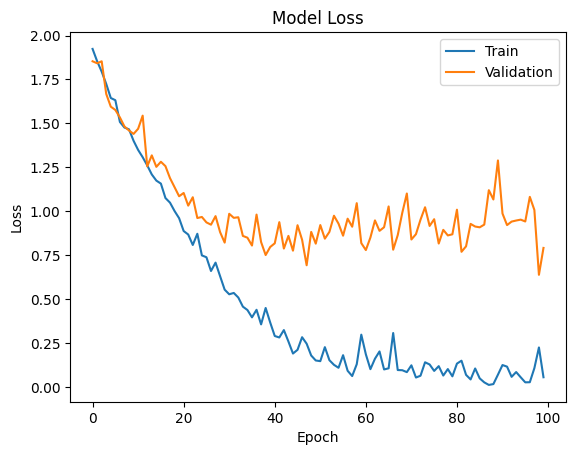

In [44]:
# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

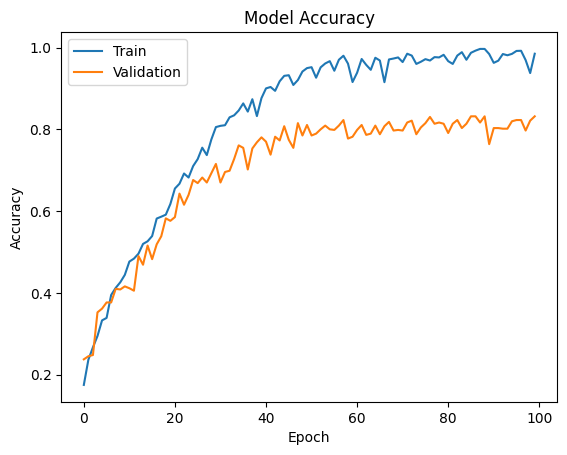

In [45]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

26/26 [==============================] - 1s 21ms/step


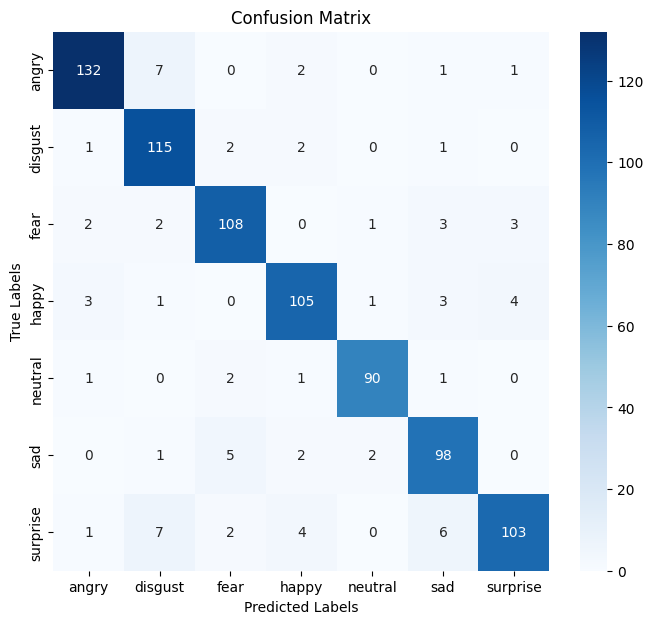

              precision    recall  f1-score   support

       angry       0.94      0.92      0.93       143
     disgust       0.86      0.95      0.91       121
        fear       0.91      0.91      0.91       119
       happy       0.91      0.90      0.90       117
     neutral       0.96      0.95      0.95        95
         sad       0.87      0.91      0.89       108
    surprise       0.93      0.84      0.88       123

    accuracy                           0.91       826
   macro avg       0.91      0.91      0.91       826
weighted avg       0.91      0.91      0.91       826



In [52]:
# Get the predicted labels for the test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)  # Convert one-hot encoded predictions to labels

# Convert the true labels from one-hot encoding to labels
y_true_labels = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad','surprise']  # Replace with your actual class names
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, labels=range(len(class_names)))

# Display the confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
print(report)

In [22]:
print(report)

              precision    recall  f1-score   support

       angry       0.97      1.00      0.98        91
     disgust       0.00      0.00      0.00         0
        fear       1.00      1.00      1.00        89
       happy       1.00      0.97      0.98        92
     neutral       1.00      1.00      1.00        80
         sad       1.00      1.00      1.00        97
    surprise       1.00      1.00      1.00        81

   micro avg       0.99      0.99      0.99       530
   macro avg       0.85      0.85      0.85       530
weighted avg       0.99      0.99      0.99       530



In [51]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32)

Epoch 1/100
83/83 [==============================] - 4s 52ms/step - loss: 0.0194 - accuracy: 0.9958 - val_loss: 0.0118 - val_accuracy: 0.9955
Epoch 2/100
83/83 [==============================] - 4s 50ms/step - loss: 0.0219 - accuracy: 0.9951 - val_loss: 0.1155 - val_accuracy: 0.9713
Epoch 3/100
83/83 [==============================] - 4s 49ms/step - loss: 0.1136 - accuracy: 0.9735 - val_loss: 0.0311 - val_accuracy: 0.9939
Epoch 4/100
83/83 [==============================] - 4s 52ms/step - loss: 0.0322 - accuracy: 0.9924 - val_loss: 0.0416 - val_accuracy: 0.9894
Epoch 5/100
83/83 [==============================] - 5s 56ms/step - loss: 0.1358 - accuracy: 0.9633 - val_loss: 0.3370 - val_accuracy: 0.9047
Epoch 6/100
83/83 [==============================] - 4s 50ms/step - loss: 0.1138 - accuracy: 0.9731 - val_loss: 0.1622 - val_accuracy: 0.9592
Epoch 7/100
83/83 [==============================] - 5s 61ms/step - loss: 0.0925 - accuracy: 0.9777 - val_loss: 0.0644 - val_accuracy: 0.9818
Epoch 

In [28]:
print("Accuracy of our model on train data : " , model.evaluate(X_train,y_train)[1]*100 , "%")

104/104 [==============================] - 1s 10ms/step - loss: 0.1640 - accuracy: 0.9658
Accuracy of our model on train data :  96.57782912254333 %


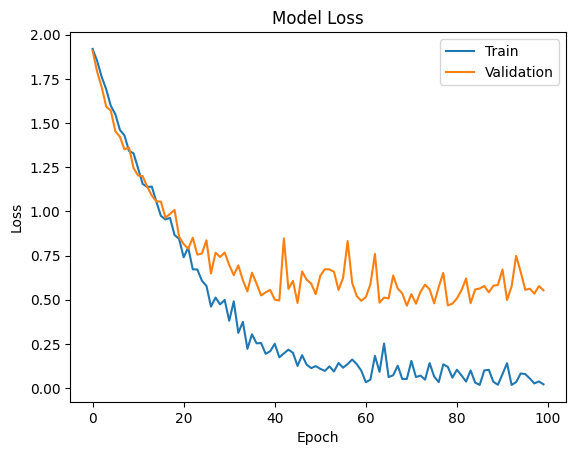

In [50]:
# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [29]:
model.save('audio_lstm.h5')